In [38]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import japanize_matplotlib
import matplotlib.gridspec as gridspec
import seaborn as sns

# グラフをアウトプット行に出力するためのマジックコマンド
%matplotlib inline

In [39]:
train = pd.read_csv('../../data/raw/train.csv')
test = pd.read_csv('../../data/raw/test.csv')

In [40]:
# 生データの表示
train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15731148.0,Ch'ien,732.0,France,Male,35.0,2.0,125785.23,2.0,1.0,0.0,52367.29,0.0
1,1,15804002.0,Onyeoruru,704.0,France,Male,31.0,1.0,118788.57,1.0,1.0,0.0,96864.56,0.0
2,2,15663478.0,Akobundu,706.0,Spain,Male,35.0,1.0,0.00,2.0,1.0,0.0,147040.25,0.0
3,3,15623072.0,Fanucci,850.0,France,Male,34.0,1.0,0.00,2.0,1.0,1.0,141679.71,0.0
4,4,15702293.0,Mironova,468.0,Spain,Male,36.0,9.0,0.00,1.0,1.0,0.0,53584.04,0.0


In [41]:
test.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15703544.0,Uchenna,653.0,Germany,Male,45.0,3.0,116936.81,1.0,0.0,0.0,91044.47
1,15001,15688613.0,Chidiebele,549.0,Germany,Female,34.0,4.0,111927.45,1.0,1.0,0.0,149402.54
2,15002,15586880.0,Lucchese,594.0,France,Female,37.0,7.0,63723.78,2.0,1.0,0.0,152855.96
3,15003,15739046.0,Chidiebere,697.0,France,Male,37.0,3.0,0.00,2.0,0.0,1.0,149550.95
4,15004,15676521.0,Toscani,679.0,Spain,Male,25.0,2.0,0.00,2.0,1.0,1.0,103760.53


In [42]:
# データの基本統計量の確認
train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.580499e+07,659.327400,37.840667,5.063600,42015.204376,1.589133,0.777467,0.490000,117746.962851,0.204000
std,4330.271354,1.278709e+07,72.475117,8.283259,2.781955,59280.633047,0.529850,0.415961,0.499917,45416.988057,0.402982
min,0.000000,1.578130e+05,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,479.540000,0.000000
25%,3749.750000,1.563523e+07,603.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,83056.220000,0.000000
50%,7499.500000,1.569017e+07,662.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122503.545000,0.000000
75%,11249.250000,1.575784e+07,709.000000,42.000000,7.000000,108465.955000,2.000000,1.000000,1.000000,156687.270000,0.000000
max,14999.000000,1.575404e+09,850.000000,72.000000,10.000000,187534.790000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [43]:
test.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,19999.50000,1.568976e+07,657.517400,37.801800,4.992000,43139.310800,1.587200,0.777600,0.498700,117099.339826
std,2886.89568,1.583061e+05,71.954009,8.259209,2.805588,60130.981846,0.532752,0.415879,0.500023,45732.020378
min,15000.00000,1.574712e+06,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,479.540000
25%,17499.75000,1.563187e+07,603.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,82647.650000
50%,19999.50000,1.568887e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122925.400000
75%,22499.25000,1.575745e+07,707.000000,42.000000,7.000000,110939.957500,2.000000,1.000000,1.000000,155740.540000
max,24999.00000,1.581566e+07,850.000000,74.000000,10.000000,186796.370000,6.000000,1.000000,1.000000,199808.100000


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'CustomerId'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>,
        <Axes: title={'center': 'Balance'}>],
       [<Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>,
        <Axes: title={'center': 'IsActiveMember'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Exited'}>, <Axes: >]], dtype=object)

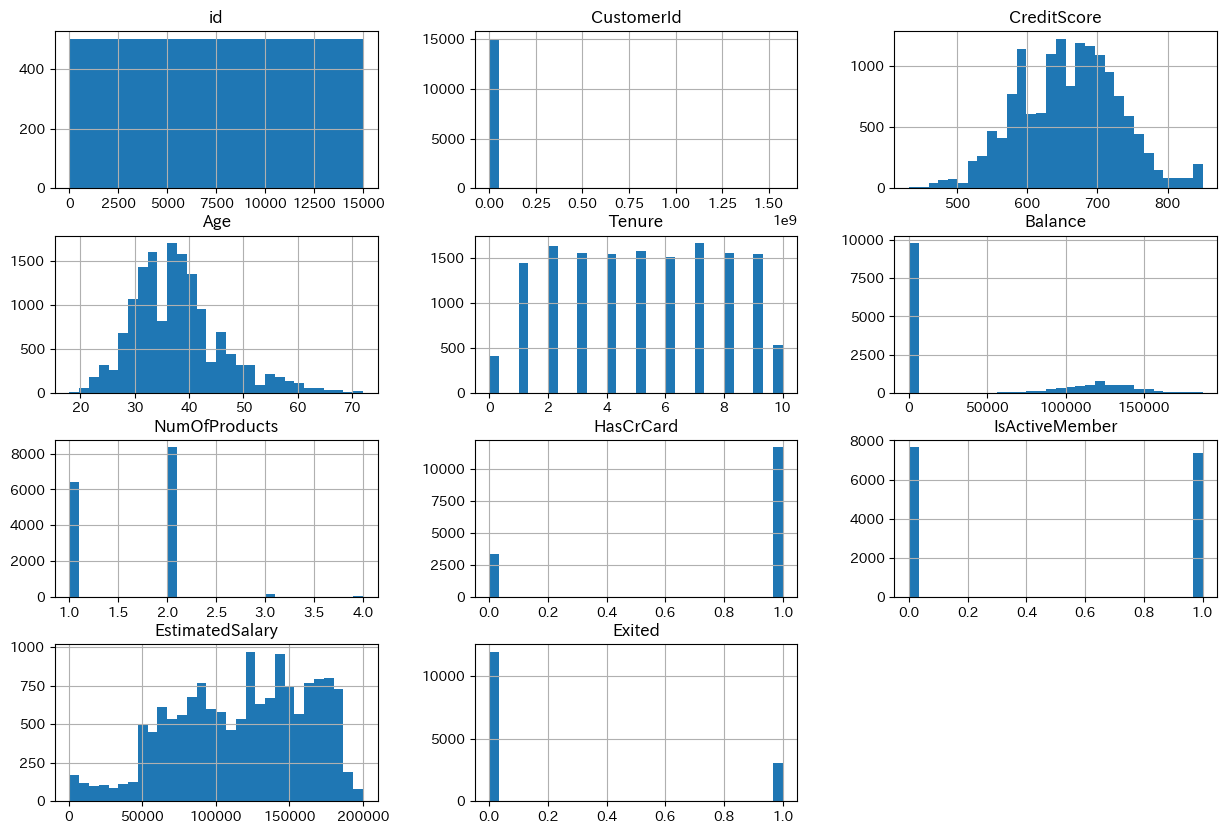

In [44]:
# 変数の分布
train.hist(bins=30, figsize=(15, 10))

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'CustomerId'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>,
        <Axes: title={'center': 'Balance'}>],
       [<Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>,
        <Axes: title={'center': 'IsActiveMember'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>, <Axes: >, <Axes: >]],
      dtype=object)

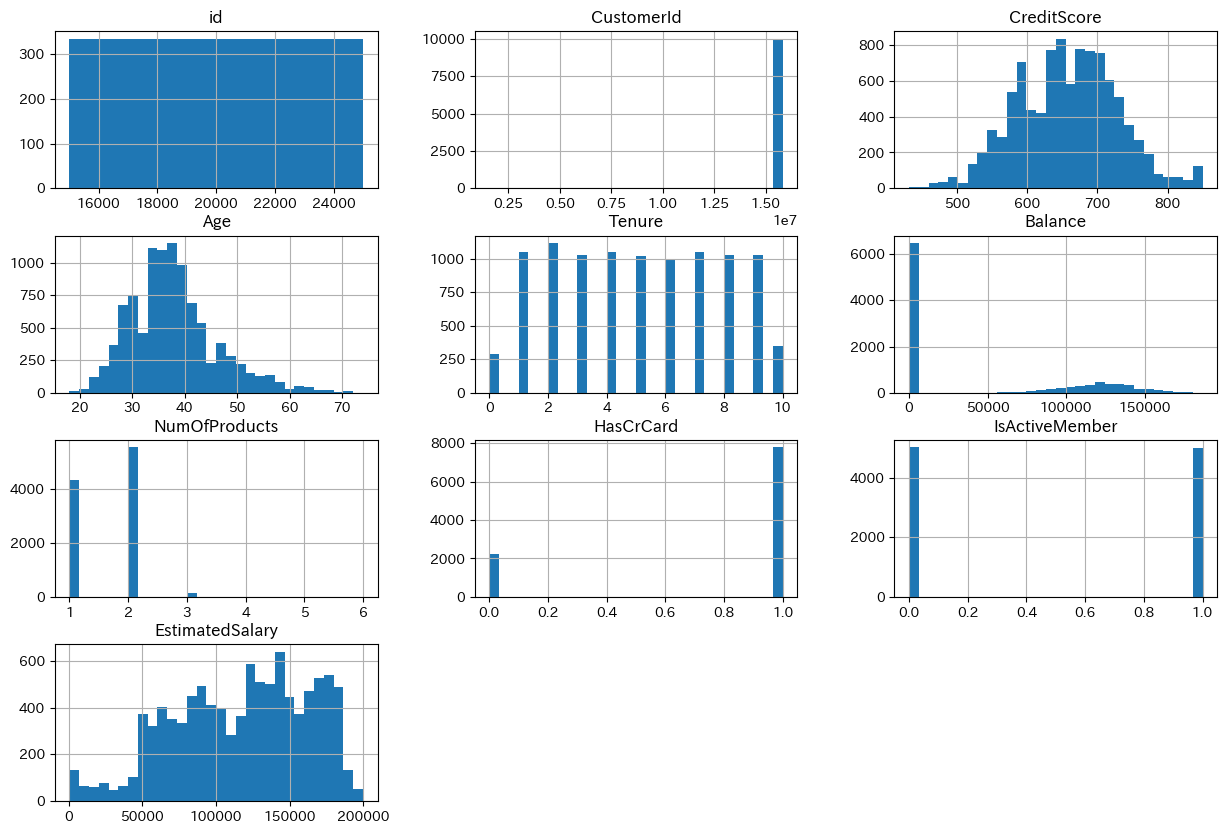

In [45]:
test.hist(bins=30, figsize=(15, 10))

### まず相関の強い変数について、解約率に差があるかの確認

In [46]:
# 年齢を10等分して、解約率に差があるか
age_bin = pd.cut(train['Age'], bins=10)
age_mean = train.groupby(age_bin)['Exited'].mean()
age_mean

Age
(17.946, 23.4]    0.037815
(23.4, 28.8]      0.043930
(28.8, 34.2]      0.048816
(34.2, 39.6]      0.102250
(39.6, 45.0]      0.293486
(45.0, 50.4]      0.614968
(50.4, 55.8]      0.763754
(55.8, 61.2]      0.673810
(61.2, 66.6]      0.417266
(66.6, 72.0]      0.147541
Name: Exited, dtype: float64

In [47]:
# 年齢を有意な差がありそうな閾値で分割し、解約率に差があるか
age_bin = pd.cut(train['Age'], bins=[0, 35, 45, 60, 65, 70, 100])
age_mean = train.groupby(age_bin)['Exited'].mean()
age_mean

Age
(0, 35]      0.053290
(35, 45]     0.194276
(45, 60]     0.674964
(60, 65]     0.470588
(65, 70]     0.194030
(70, 100]    0.047619
Name: Exited, dtype: float64

In [48]:
# 年齢を15歳から75歳まで5歳単位で分割し、解約率に差があるか
age_bin = pd.cut(train['Age'], bins=[0, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 100])
age_mean = train.groupby(age_bin)['Exited'].mean()
print(age_mean)

Age
(15, 20]    0.000000
(20, 25]    0.037879
(25, 30]    0.043435
(30, 35]    0.060922
(35, 40]    0.124813
(40, 45]    0.318750
(45, 50]    0.614968
(50, 55]    0.763754
(55, 60]    0.707182
(60, 65]    0.470588
(65, 70]    0.194030
(70, 75]    0.047619
Name: Exited, dtype: float64


Age
(20.5, 21.5]    0.052632
(21.5, 22.5]    0.068493
(22.5, 23.5]    0.020000
(23.5, 24.5]    0.044444
(24.5, 25.5]    0.027473
(25.5, 26.5]    0.074803
(26.5, 27.5]    0.018182
(27.5, 28.5]    0.049261
(28.5, 29.5]    0.040210
(29.5, 30.5]    0.040323
(30.5, 31.5]    0.043042
(31.5, 32.5]    0.045144
(32.5, 33.5]    0.074589
(33.5, 34.5]    0.043210
(34.5, 35.5]    0.094828
(35.5, 36.5]    0.079602
(36.5, 37.5]    0.098214
(37.5, 38.5]    0.089412
(38.5, 39.5]    0.155647
(39.5, 40.5]    0.216802
(40.5, 41.5]    0.196370
(41.5, 42.5]    0.286585
(42.5, 43.5]    0.356828
(43.5, 44.5]    0.348442
(44.5, 45.5]    0.504478
(45.5, 46.5]    0.543662
(46.5, 47.5]    0.609649
(47.5, 48.5]    0.613527
(48.5, 49.5]    0.701657
(49.5, 50.5]    0.695652
(50.5, 51.5]    0.812500
(51.5, 52.5]    0.751773
(52.5, 53.5]    0.666667
(53.5, 54.5]    0.777778
(54.5, 55.5]    0.761468
(55.5, 56.5]    0.896226
(56.5, 57.5]    0.686567
(57.5, 58.5]    0.535211
(58.5, 59.5]    0.615385
(59.5, 60.5]    0.698

<Axes: xlabel='Age'>

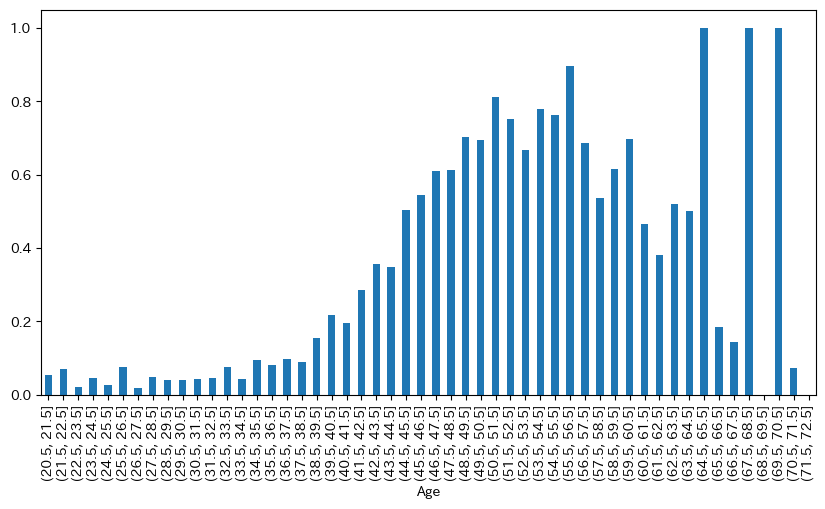

In [49]:
age_bin = pd.cut(train['Age'], bins=[20.5,21.5,22.5,23.5,24.5,25.5,26.5,27.5,28.5,29.5,30.5,31.5,32.5,33.5,34.5,35.5,36.5,37.5,38.5,39.5,40.5,41.5,42.5,43.5,44.5,45.5,46.5,47.5,48.5,49.5,50.5,51.5,52.5,53.5,54.5,55.5,56.5,57.5,58.5,59.5,60.5,61.5,62.5,63.5,64.5,65.5,66.5,67.5,68.5,69.5,70.5,71.5,72.5,73.5,74.5,75.5,100.5])
age_mean = train.groupby(age_bin)['Exited'].mean()
print(age_mean)
age_mean.plot(kind='bar', figsize=(10, 5))

In [50]:
age_bin = pd.cut(train['Age'], bins=[20.5,21.5,22.5,23.5,24.5,25.5,26.5,27.5,28.5,29.5,30.5,31.5,32.5,33.5,34.5,35.5,36.5,37.5,38.5,39.5,40.5,41.5,42.5,43.5,44.5,45.5,46.5,47.5,48.5,49.5,50.5,51.5,52.5,53.5,54.5,55.5,56.5,57.5,58.5,59.5,60.5,61.5,62.5,63.5,64.5,65.5,66.5,67.5,68.5,69.5,70.5,71.5,72.5,73.5,74.5,75.5,100.5])
age_count = train.groupby(age_bin)['Exited'].count()
print(age_count)

Age
(20.5, 21.5]     38
(21.5, 22.5]     73
(22.5, 23.5]    100
(23.5, 24.5]    135
(24.5, 25.5]    182
(25.5, 26.5]    254
(26.5, 27.5]    275
(27.5, 28.5]    406
(28.5, 29.5]    572
(29.5, 30.5]    496
(30.5, 31.5]    697
(31.5, 32.5]    731
(32.5, 33.5]    791
(33.5, 34.5]    810
(34.5, 35.5]    812
(35.5, 36.5]    804
(36.5, 37.5]    896
(37.5, 38.5]    850
(38.5, 39.5]    726
(39.5, 40.5]    738
(40.5, 41.5]    606
(41.5, 42.5]    492
(42.5, 43.5]    454
(43.5, 44.5]    353
(44.5, 45.5]    335
(45.5, 46.5]    355
(46.5, 47.5]    228
(47.5, 48.5]    207
(48.5, 49.5]    181
(49.5, 50.5]    138
(50.5, 51.5]    176
(51.5, 52.5]    141
(52.5, 53.5]     84
(53.5, 54.5]    108
(54.5, 55.5]    109
(55.5, 56.5]    106
(56.5, 57.5]     67
(57.5, 58.5]     71
(58.5, 59.5]     65
(59.5, 60.5]     53
(60.5, 61.5]     58
(61.5, 62.5]     50
(62.5, 63.5]     27
(63.5, 64.5]     30
(64.5, 65.5]      5
(65.5, 66.5]     27
(66.5, 67.5]     28
(67.5, 68.5]      2
(68.5, 69.5]      8
(69.5, 70.5]    

Age
(0, 35]      0.053290
(35, 45]     0.194276
(45, 60]     0.674964
(60, 65]     0.470588
(65, 100]    0.159091
Name: Exited, dtype: float64


<Axes: xlabel='Age'>

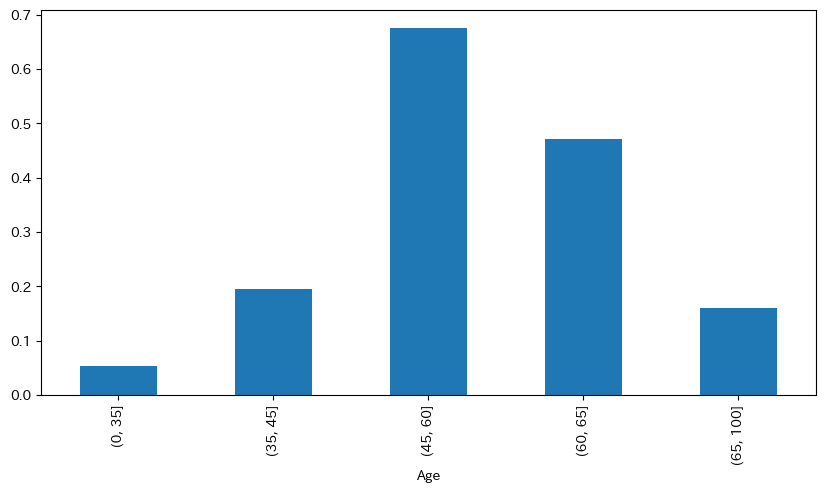

In [51]:
age_bin = pd.cut(train['Age'], bins=[0, 35, 45, 60, 65, 100])
age_mean = train.groupby(age_bin)['Exited'].mean()
print(age_mean)
age_mean.plot(kind='bar', figsize=(10, 5))

Balance
(-187.535, 18753.479]       0.158023
(37506.958, 56260.437]      0.200000
(56260.437, 75013.916]      0.198276
(75013.916, 93767.395]      0.211581
(93767.395, 112520.874]     0.298587
(112520.874, 131274.353]    0.347278
(131274.353, 150027.832]    0.255928
(150027.832, 168781.311]    0.256790
(168781.311, 187534.79]     0.263636
Name: Exited, dtype: float64


<Axes: xlabel='Balance'>

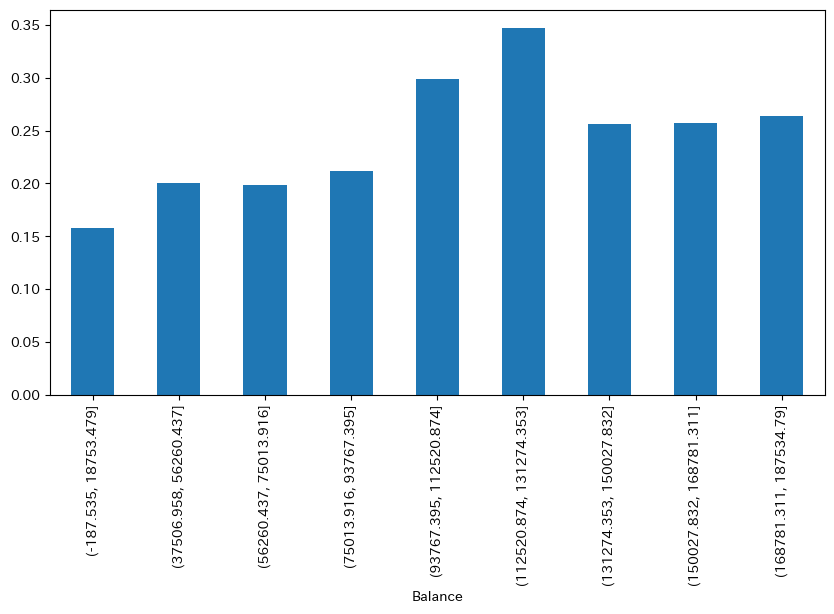

In [52]:
# 口座残高を10等分して、解約率に差があるか
balance_bin = pd.cut(train['Balance'], bins=10)
balance_mean = train.groupby(balance_bin)['Exited'].mean()
print(balance_mean)
balance_mean.plot(kind='bar', figsize=(10, 5))

In [53]:
# 銀行製品数によって解約率に差があるか
products_mean = train.groupby('NumOfProducts')['Exited'].mean()
products_mean

NumOfProducts
1.0    0.389659
2.0    0.040943
3.0    0.953608
4.0    0.968750
Name: Exited, dtype: float64

In [54]:
products_number = train['NumOfProducts'].value_counts()
products_number

NumOfProducts
2.0    8353
1.0    6421
3.0     194
4.0      32
Name: count, dtype: int64

In [55]:
# アクティブ会員かどうかで解約率に差があるか
active_mean = train.groupby('IsActiveMember')['Exited'].mean()
active_mean

IsActiveMember
0.0    0.285752
1.0    0.118912
Name: Exited, dtype: float64

---

In [56]:
# クレジットカードの有無で解約率に差があるか
hascard_mean = train.groupby('HasCrCard')['Exited'].mean()
hascard_mean

HasCrCard
0.0    0.207909
1.0    0.202881
Name: Exited, dtype: float64

In [57]:
# 地域ごとに解約率に差があるか
region_mean = train.groupby('Geography')['Exited'].mean()
region_mean

Geography
France     0.154685
Germany    0.416544
Spain      0.163278
Name: Exited, dtype: float64

In [58]:
# 信用スコアを10等分して、解約率に差があるか
score_bin = pd.cut(train['CreditScore'], bins=10)
score_mean = train.groupby(score_bin)['Exited'].mean()
score_mean

CreditScore
(430.581, 472.9]    0.309859
(472.9, 514.8]      0.265957
(514.8, 556.7]      0.261053
(556.7, 598.6]      0.210004
(598.6, 640.5]      0.231959
(640.5, 682.4]      0.200246
(682.4, 724.3]      0.166667
(724.3, 766.2]      0.205702
(766.2, 808.1]      0.182163
(808.1, 850.0]      0.171582
Name: Exited, dtype: float64

In [59]:
# 性別によって解約率に差があるか
gender_mean = train.groupby('Gender')['Exited'].mean()
gender_mean

Gender
Female    0.284215
Male      0.141382
Name: Exited, dtype: float64

In [60]:
# 取引年数を10等分して、解約率に差があるか
tenure_bin = pd.cut(train['Tenure'], bins=10)
tenure_mean = train.groupby(tenure_bin)['Exited'].mean()
tenure_mean

Tenure
(-0.01, 1.0]    0.254037
(1.0, 2.0]      0.184098
(2.0, 3.0]      0.215800
(3.0, 4.0]      0.200645
(4.0, 5.0]      0.208096
(5.0, 6.0]      0.194059
(6.0, 7.0]      0.174955
(7.0, 8.0]      0.183687
(8.0, 9.0]      0.211886
(9.0, 10.0]     0.209434
Name: Exited, dtype: float64

In [61]:
# 給与を10等分して、解約率に差があるか
salary_bin = pd.cut(train['EstimatedSalary'], bins=10)
salary_mean = train.groupby(salary_bin)['Exited'].mean()
salary_mean

EstimatedSalary
(280.027, 20430.834]        0.194872
(20430.834, 40382.128]      0.182119
(40382.128, 60333.422]      0.212687
(60333.422, 80284.716]      0.179262
(80284.716, 100236.01]      0.183643
(100236.01, 120187.304]     0.216182
(120187.304, 140138.598]    0.193237
(140138.598, 160089.892]    0.203712
(160089.892, 180041.186]    0.238901
(180041.186, 199992.48]     0.212000
Name: Exited, dtype: float64

In [62]:
# 推定年収を10等分して、解約率に差があるか
salary_bin = pd.cut(train['EstimatedSalary'], bins=10)
salary_mean = train.groupby(salary_bin)['Exited'].mean()
salary_mean

EstimatedSalary
(280.027, 20430.834]        0.194872
(20430.834, 40382.128]      0.182119
(40382.128, 60333.422]      0.212687
(60333.422, 80284.716]      0.179262
(80284.716, 100236.01]      0.183643
(100236.01, 120187.304]     0.216182
(120187.304, 140138.598]    0.193237
(140138.598, 160089.892]    0.203712
(160089.892, 180041.186]    0.238901
(180041.186, 199992.48]     0.212000
Name: Exited, dtype: float64

In [63]:
train.groupby('NumOfProducts')['Exited'].agg(['mean', 'count'])

,mean,count
NumOfProducts,,
1.0,0.389659,6421
2.0,0.040943,8353
3.0,0.953608,194
4.0,0.968750,32


In [64]:
# 製品数
# 3つ以上の製品を持っているユーザーのサンプル数が少ないため、3以上として扱う
# 精度は下がった
# train['NumOfProducts'] = train['NumOfProducts'].apply(lambda x: 3 if x >= 3 else x)
# test['NumOfProducts'] = test['NumOfProducts'].apply(lambda x: 3 if x >= 3 else x)


In [65]:
train.groupby('NumOfProducts')['Exited'].agg(['mean', 'count'])

,mean,count
NumOfProducts,,
1.0,0.389659,6421
2.0,0.040943,8353
3.0,0.953608,194
4.0,0.968750,32


---

In [66]:
# 口座残高と推定年収の比率を新しい特徴量として追加
# 効果なし
train['Balance_Salary_Ratio'] = train['Balance'] / (train['EstimatedSalary'] + 1)  # +1はゼロ割防止のため
test['Balance_Salary_Ratio'] = test['Balance'] / (test['EstimatedSalary'] + 1)  # +1はゼロ割防止のため

In [67]:
# 口座残高がゼロかどうかを示すフラグを新しい特徴量として追加
# 効果なし
train['Balance_Zero_Flag'] = (train['Balance'] == 0).astype(int)
test['Balance_Zero_Flag'] = (test['Balance'] == 0).astype(int)

In [68]:
# 銀行製品数とアクティブかどうかの組み合わせで解約率に差があるか
train.groupby(['NumOfProducts', 'IsActiveMember'])['Exited'].agg(['mean', 'count'])

mean  count
NumOfProducts IsActiveMember                 
1.0           0.0             0.505204   3555
              1.0             0.246336   2866
2.0           0.0             0.060152   3940
              1.0             0.023793   4413
3.0           0.0             0.984962    133
              1.0             0.885246     61
4.0           0.0             1.000000     22
              1.0             0.900000     10

In [69]:
# カードを持っているかと取引年数の組み合わせで解約率に差があるか
train.groupby(['HasCrCard', 'Tenure'])['Exited'].agg(['mean', 'count'])

mean  count
HasCrCard Tenure                 
0.0       0.0     0.252747     91
          1.0     0.253644    343
          2.0     0.193182    352
          3.0     0.204403    318
          4.0     0.195402    348
          5.0     0.196286    377
          6.0     0.213213    333
          7.0     0.193084    347
          8.0     0.186667    375
          9.0     0.230539    334
          10.0    0.200000    120
1.0       0.0     0.284375    320
          1.0     0.245471   1104
          2.0     0.181606   1283
          3.0     0.218725   1239
          4.0     0.202163   1202
          5.0     0.211794   1204
          6.0     0.188663   1182
          7.0     0.170197   1322
          8.0     0.182741   1182
          9.0     0.206755   1214
          10.0    0.212195    410